In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

Week 2 Task:

• Load a minimum of 6 months of dataset into pandas. (May 2025 ~ May 2026)

• Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, 
Bathrooms, LotSize.

• Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc).

• Deliverable: Jupyter notebook 01_exploration.ipynb with basic EDA plots.


In [64]:
"""
- Extract and combine sales data from May 2025 to May 2026
- Retrict analysis to PropertyType = 'Residential' & 'PropertySubtype' = 'SingleFamilyResidence'
"""

path = "../data/all_sales_data/"
target_months = [f"2025{m:02d}" for m in range(5,13)] + [f"2026{m:02d}" for m in range(1,6)]

all_files = []
for month in target_months:
    file_name = f"CRMLSSold{month}.csv"
    file_path = os.path.join(path, file_name)
    if os.path.exists(file_path):
        all_files.append(file_path)
    else:
        print(f"File not found: {file_path}")
    
if all_files:
    df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    print(f"Combined DataFrame shape: {df.shape}")
else:
    print("No files found for the specified months.")

df_restricted = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")]



C:\Users\kelvi\AppData\Local\Temp\ipykernel_18204\4110022959.py:19: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
C:\Users\kelvi\AppData\Local\Temp\ipykernel_18204\4110022959.py:19: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)


Combined DataFrame shape: (281823, 78)


__EDA__

In [89]:
#Sainty Check
cols_to_explore = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
print(df_restricted[cols_to_explore].describe())

for col in cols_to_explore:
    num_na = df_restricted[col].isna().sum()
    print(f"{col} have {num_na} missing values")

         ClosePrice     LivingArea  BedroomsTotal  BathroomsTotalInteger  \
count  1.419970e+05  141919.000000  141997.000000          141984.000000   
mean   1.344654e+06    2048.649644       3.492581               2.632452   
std    8.084465e+06    1044.085649       0.963529               1.131934   
min    0.000000e+00       0.000000       0.000000               0.000000   
25%    6.250000e+05    1386.000000       3.000000               2.000000   
50%    8.900000e+05    1820.000000       3.000000               2.000000   
75%    1.425000e+06    2440.000000       4.000000               3.000000   
max    9.895000e+08   56500.000000      22.000000              35.000000   

       LotSizeSquareFeet  
count       1.395640e+05  
mean        3.710659e+05  
std         1.744801e+07  
min         0.000000e+00  
25%         5.663000e+03  
50%         7.289000e+03  
75%         1.045400e+04  
max         1.938943e+09  
ClosePrice have 0 missing values
LivingArea have 78 missing values
Bedro

Explore Continuous Data

Feature: ClosePrice           | 99th Pctl: 6400000.00 |1th Pctl:  235000.00 | Filtered:  2778 | Remaining: 139219
Feature: LivingArea           | 99th Pctl:    5120.00 |1th Pctl:     753.00 | Filtered:  2778 | Remaining: 136388
Feature: LotSizeSquareFeet    | 99th Pctl:  242629.14 |1th Pctl:    1767.00 | Filtered:  2681 | Remaining: 131349

Final dataset retention: 92.50%


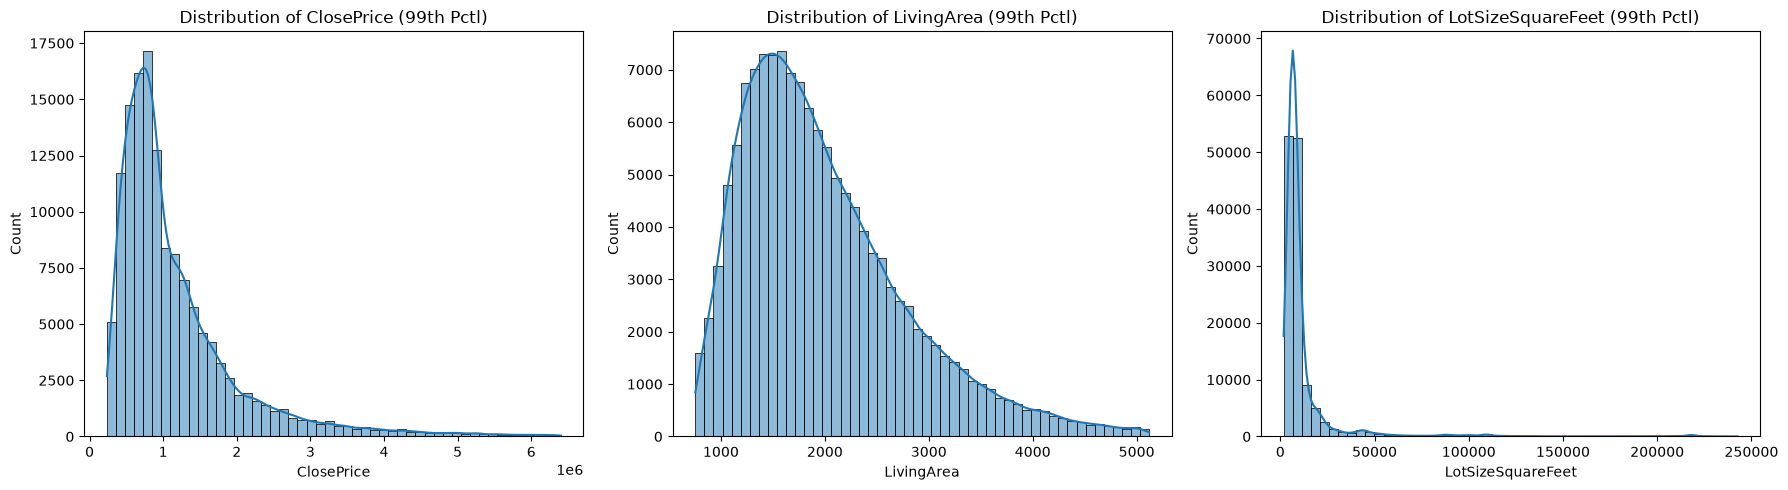

In [102]:
continuous_col = ["ClosePrice", "LivingArea", "LotSizeSquareFeet"]
total_records = len(df_restricted)
current_df = df_restricted.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 

for i, feature in enumerate(continuous_col):
    lower_limit = current_df[feature].quantile(0.01)
    upper_limit = current_df[feature].quantile(0.99)

    outliers_count = len(current_df[(current_df[feature] > upper_limit) | (current_df[feature] < lower_limit)])

    current_df = current_df[(current_df[feature] <= upper_limit) & ((current_df[feature] >= lower_limit)) ]
    print(f"Feature: {feature:20} | 99th Pctl: {upper_limit:10.2f} |1th Pctl: {lower_limit:10.2f} | Filtered: {outliers_count:5} | Remaining: {len(current_df):6}")
    sns.histplot(current_df[feature], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} (99th Pctl)')

print(f"\nFinal dataset retention: {len(current_df) / total_records:.2%}")
plt.tight_layout()
plt.show()

Explore Discrete Data

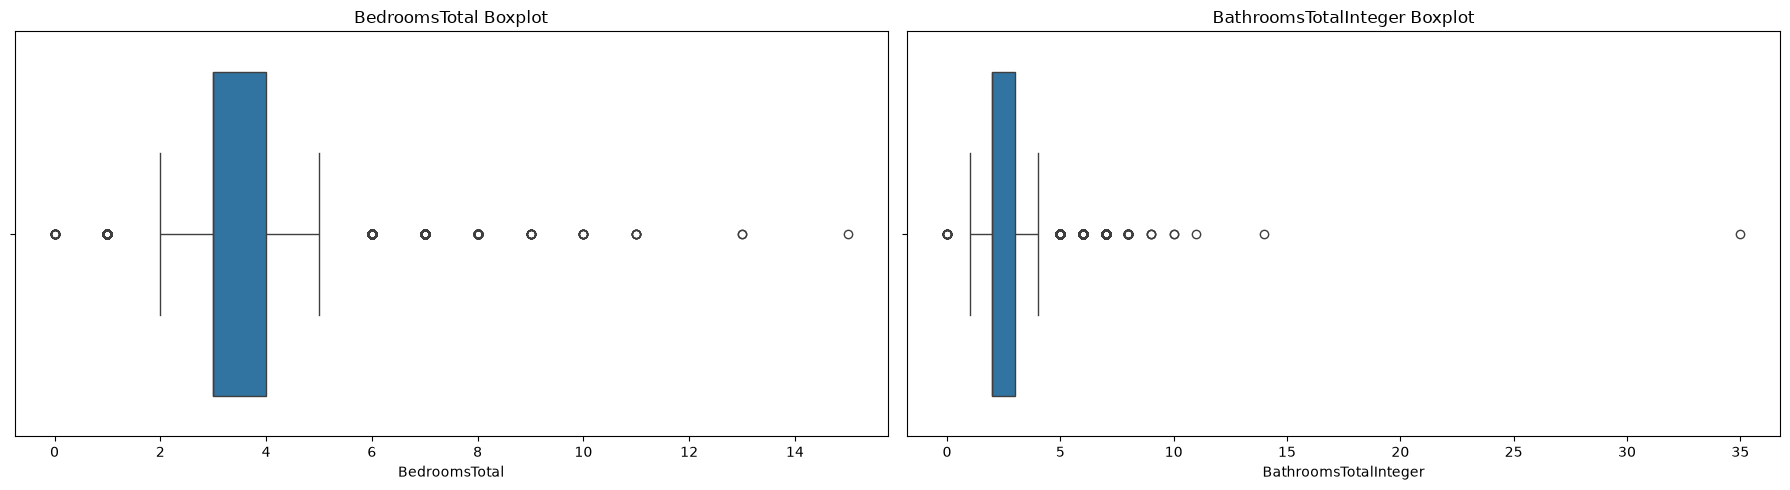

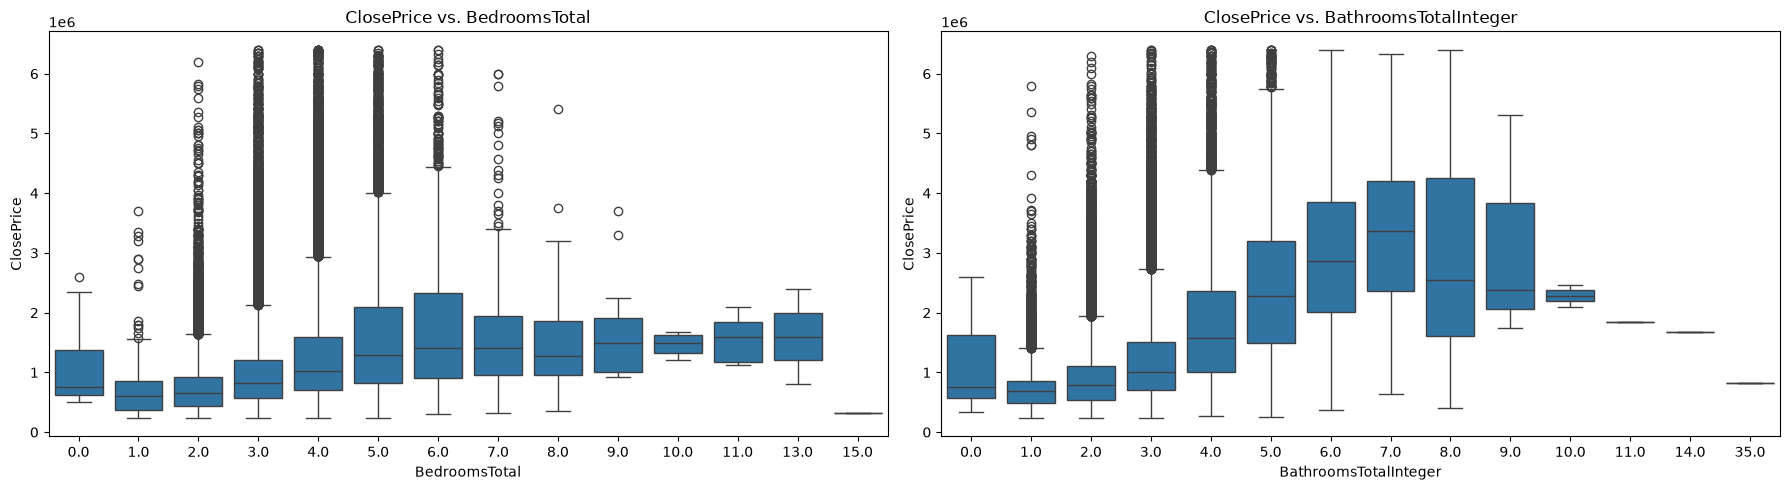

In [115]:
compare_col = ["BedroomsTotal", "BathroomsTotalInteger"]
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for i, col in enumerate(compare_col):
    sns.boxplot(data = current_df, x = col, ax = axes[i])
    axes[i].set_title(f"{col} Boxplot")
plt.tight_layout()


fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for i, col in enumerate(compare_col):
    sns.boxplot(data = current_df, x = col, y = "ClosePrice", ax = axes[i])
    axes[i].set_title(f"ClosePrice vs. {col}")
plt.tight_layout()
plt.show()



Correlation Heatmap

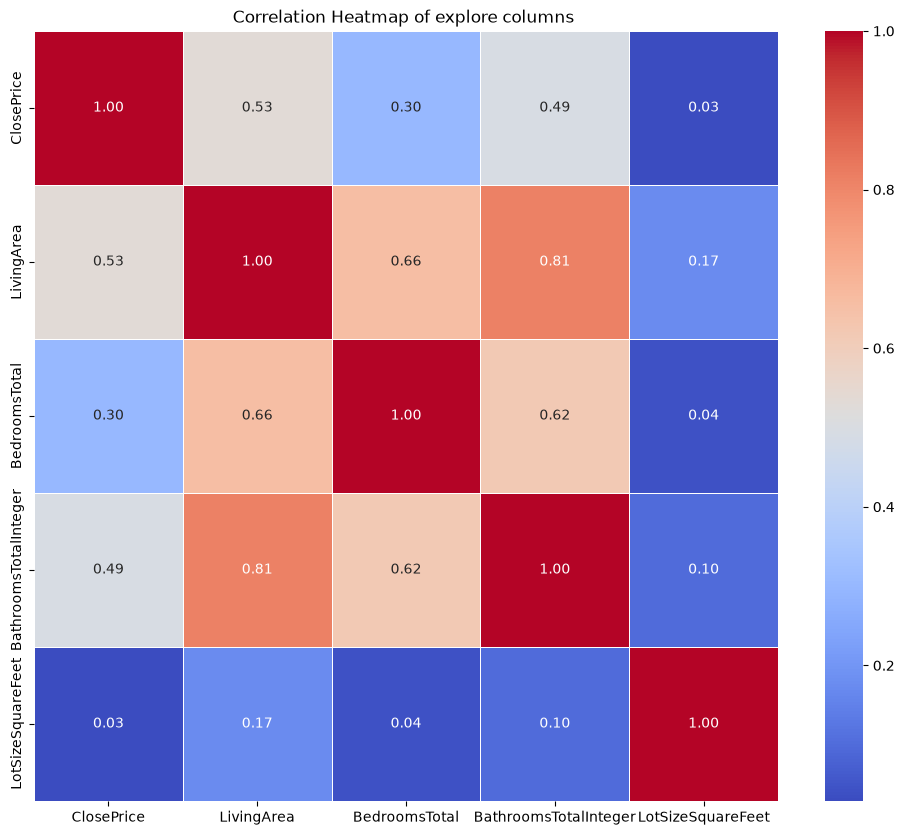

In [104]:
corr_matrix = current_df[cols_to_explore].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of explore columns ')
plt.show()